In [ ]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
import models
import torch
import torch.nn as nn 
from tqdm import tqdm
import importlib

c:\Users\jerry\anaconda3\envs\allensdk\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def c():
    import gc 
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

def modelreload():
    import models
    importlib.reload(models)
    import models
    input_size = 623
    seq_length = 100
    num_layers = 1
    num_hidden = 50
    device = 'cuda'
    criterion = nn.MSELoss()
    model = models.process_model(models.LSTMnet(input_size, num_hidden, num_layers, seq_length), criterion, device)
    model = model.load_model(r"F:\lstm_model_chan5_band0.pt").to(device)
    return model

device = 'cuda'


In [3]:
spikes = np.load(r"F:\spikes.npy")

### Without using unsqueeze(), avoid batch norm temporarily

Input shape: torch.Size([37500, 623])
Output shape: torch.Size([37500, 1])


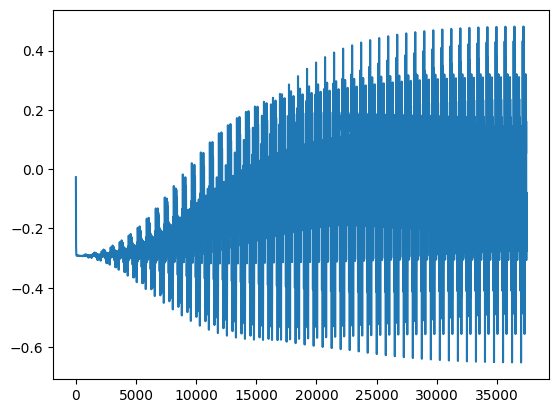

In [45]:
X_attr = spikes[:int(720/3*750),:]
X_attr = torch.tensor(X_attr).float()
X_attr = X_attr.reshape(240,750,623)
attributions = []
for i in range(X_attr.shape[0]):
    ig = IntegratedGradients(model)
    attr = ig.attribute(X_attr[i].to(device), target=0, n_steps=50)
    attributions.append(attr)
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()

Text(0.5, 1.0, 'Integrated Gradients, no BN, np unsqueeze')

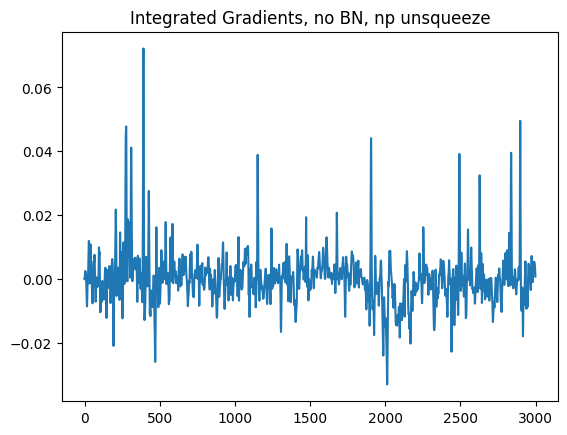

In [48]:
plt.plot(attributions[:3000, 0])
plt.title("Integrated Gradients, no BN, np unsqueeze")

### Using unsqueeze() and batch norm

Input shape: torch.Size([50, 750, 623])
Output shape: torch.Size([50, 750, 1])


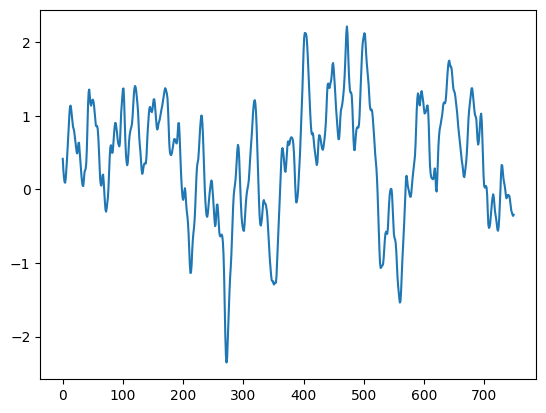

In [54]:
X_attr = spikes[:int(720/3*750),:]
X_attr = torch.tensor(X_attr).float()
X_attr = X_attr.reshape(240,750,623)
attributions = []
for i in range(X_attr.shape[0]):
    ig = IntegratedGradients(model)
    attr = ig.attribute(X_attr[i].unsqueeze(0).to(device), target=0, n_steps=50)
    attributions.append(attr)
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()

Text(0.5, 1.0, 'Integrated Gradients, BN, unsqueezed')

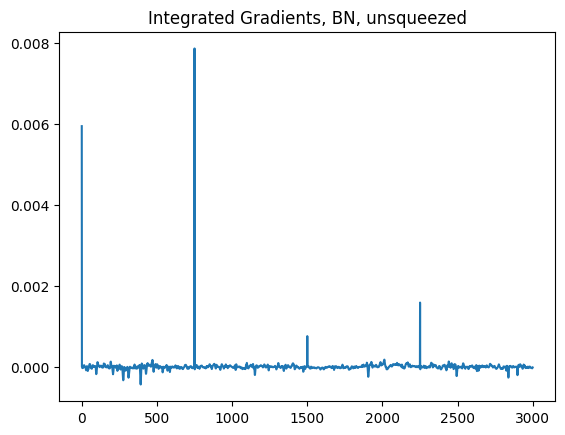

In [58]:
attributions = attributions.reshape(240*750, 623)
plt.plot(attributions[:3000, 0])
plt.title("Integrated Gradients, BN, unsqueezed")

### Using unsqueeze() in batch and batch norm

Input shape: torch.Size([400, 750, 623])
Output shape: torch.Size([400, 750, 1])


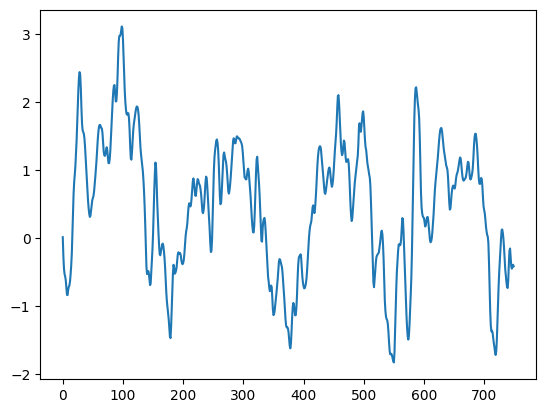

In [5]:
X_attr = spikes[:int(8*30*750),:]
X_attr = torch.tensor(X_attr).float()
X_attr = X_attr.reshape(240,750,623)
X_attr = X_attr.reshape(30,8,750,623)
attributions = []
ig = IntegratedGradients(model)
for i in range(X_attr.shape[0]):
    temp = X_attr[i].to(device)
    attr = ig.attribute(temp, target=0, n_steps=50)
    attributions.append(attr)
    del temp
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()

Text(0.5, 1.0, 'Integrated Gradients, BN, unsqueezed in Batches')

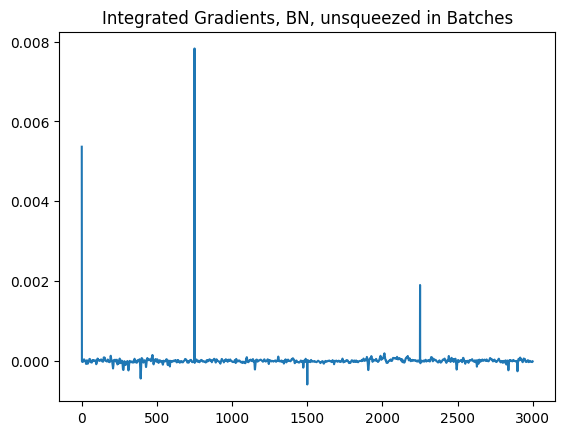

In [11]:
attributions = attributions.reshape(30*8*750, 623)
plt.plot(attributions[:3000, 0])
plt.title("Integrated Gradients, BN, unsqueezed in Batches")

### Using unsqueeze() again, not in batches to save VRAM, now try target = 10

In [7]:
model = modelreload()
X_attr = spikes[:int(720/3*750),:]
X_attr = torch.tensor(X_attr).float()
X_attr = X_attr.reshape(240,750,623)
attributions = []
for i in range(X_attr.shape[0]):
    ig = IntegratedGradients(model)
    attr = ig.attribute(X_attr[i].unsqueeze(0).to(device), target=10, n_steps=50)
    attributions.append(attr)
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()  

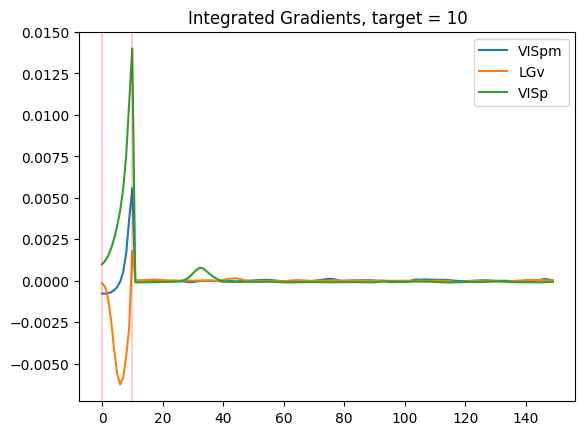

In [8]:
attributions = attributions.reshape(30*8*750, 623)
plt.plot(attributions[:150, 0], label = 'VISpm')
plt.plot(attributions[:150, 244], label = 'LGv')
plt.plot(attributions[:150, 206], label = 'VISp')

plt.title("Integrated Gradients, target = 10")
plt.axvline(0, c='r', alpha=0.2)
plt.axvline(10, c='r', alpha=0.2)
plt.legend()

### try again with target = 50

In [12]:
model = modelreload()
X_attr = spikes[:int(720/3*750),:]
X_attr = torch.tensor(X_attr).float()
X_attr = X_attr.reshape(240,750,623)
attributions = []
for i in range(X_attr.shape[0]):
    ig = IntegratedGradients(model)
    attr = ig.attribute(X_attr[i].unsqueeze(0).to(device), target=50, n_steps=50)
    attributions.append(attr)
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()  

VISpm average attribution: 0.00015604804188749377
LGv average attribution: 0.00016121590547632297
VISp average attribution: 0.0004926166558741344


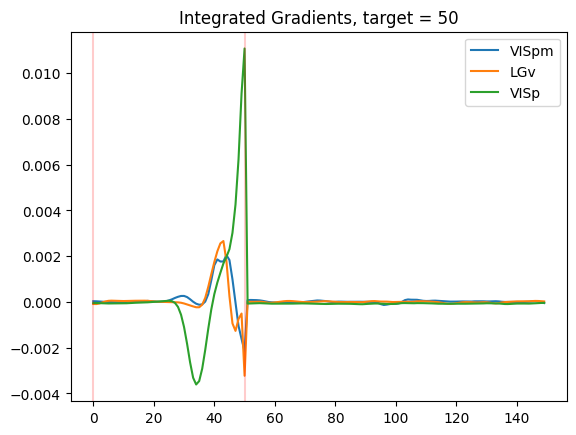

In [20]:
attributions = attributions.reshape(30*8*750, 623)
plt.plot(attributions[:150, 0], label = 'VISpm')
plt.plot(attributions[:150, 244], label = 'LGv')
plt.plot(attributions[:150, 206], label = 'VISp')
print(f"VISpm average attribution: {np.mean(np.abs(attributions[:150, 0]))}")
print(f"LGv average attribution: {np.mean(np.abs(attributions[:150, 244]))}")
print(f"VISp average attribution: {np.mean(np.abs(attributions[:150, 206]))}")
plt.title("Integrated Gradients, target = 50")
plt.axvline(0, c='r', alpha=0.2)
plt.axvline(50, c='r', alpha=0.2)
plt.legend()

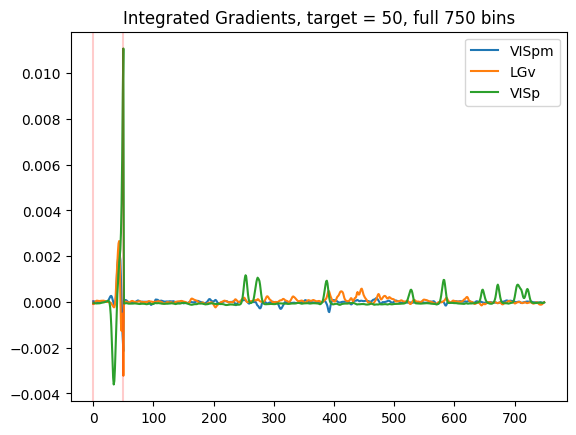

In [21]:
attributions = attributions.reshape(30*8*750, 623)
plt.plot(attributions[:750, 0], label = 'VISpm')
plt.plot(attributions[:750, 244], label = 'LGv')
plt.plot(attributions[:750, 206], label = 'VISp')

plt.title("Integrated Gradients, target = 50, full 750 bins")
plt.axvline(0, c='r', alpha=0.2)
plt.axvline(50, c='r', alpha=0.2)
plt.legend()

### Using 50 bins to predict last timepoint, sliding window 

In [109]:
import pandas as pd
units = pd.read_csv(r"F:\units.csv")
unique_areas = units['structure_acronym'].unique()
unique_areas = np.sort(unique_areas)
boundary = np.zeros(len(unique_areas)+1)
boundary[0] = 0
middle = np.zeros(len(unique_areas))
unique_areas_idx_flat = []
for i, area in enumerate(unique_areas):
    idx = np.where(units['structure_acronym'] == area)[0]
    boundary[i+1] = boundary[i]+len(idx)
    middle[i] = boundary[i]+int(len(idx)/2)
    unique_areas_idx_flat.extend(idx)
unique_areas_idx_flat = np.array(unique_areas_idx_flat)

In [119]:
model = modelreload()
X_attr = spikes[:int(720/3*15*30),:]
X_attr = torch.tensor(X_attr).float()
start_idx = 30 # skip the first 50 bins

attributions = np.zeros([750, 623])
ig = IntegratedGradients(model)
from tqdm import tqdm
for i in tqdm(range(750)):
    temp = X_attr[start_idx: start_idx+30, :].unsqueeze(0).to(device)
    attr = ig.attribute(temp, target=29, n_steps=50).squeeze()
    attr = np.mean(attr.cpu().detach().numpy(), axis=0)
    attributions[i] = attr
    start_idx += 1

100%|██████████| 750/750 [00:06<00:00, 123.84it/s]


In [120]:
attributions = attributions.T
attributions_rearanged = attributions[unique_areas_idx_flat]

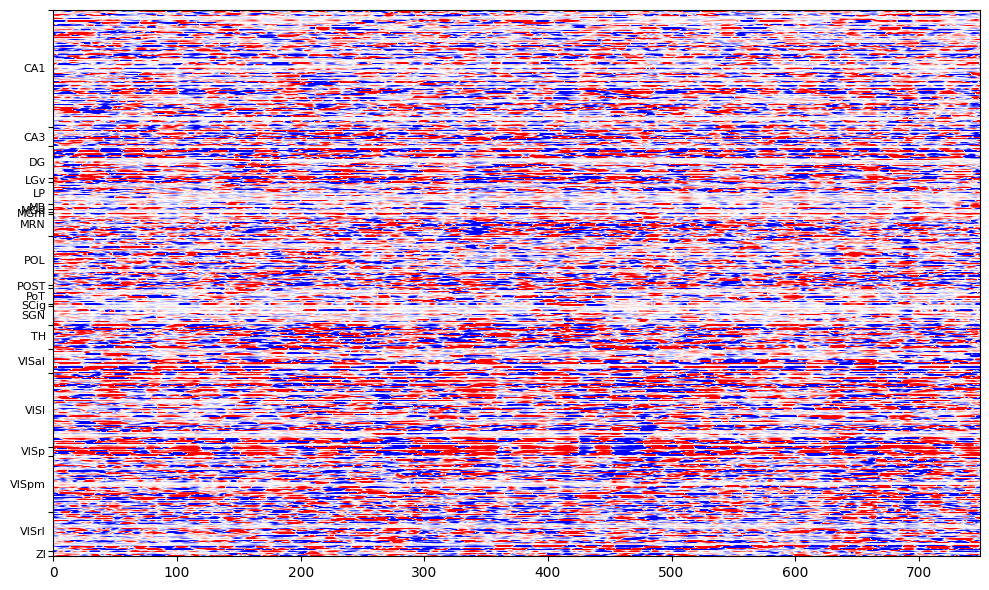

In [122]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(attributions_rearanged, aspect='auto', cmap='bwr', vmin=-0.001, vmax=0.001)
ax.set_yticks(boundary, np.array(['']*len(boundary)))
ax.set_yticks(middle, unique_areas, minor=True);
ax.tick_params(axis='y', which='minor', length=0, labelsize=8, pad=5)
plt.tight_layout()